#### House Prices Dataset
#### link: https://www.kaggle.com/c/house-prices-prediction-advanced-regression-techniques/data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv(r'data.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print(df.shape)

(1460, 81)


## Feature Engineering

In [4]:
# Drop irrelevant columns

df.drop(columns=['Id'],errors='ignore', inplace=True)

In [5]:
df.head(1)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500


## Handling Missing Values

In [6]:
#Check missing values count
missingvalues = df.isnull().sum()
missingvalues = missingvalues[missingvalues > 0].sort_values(ascending=False)
print(missingvalues)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


In [7]:
# Percentage of TRUE in Total Values
missing_percentage = df.isnull().mean().sort_values(ascending=False)
print(missing_percentage)

PoolQC         0.995205
MiscFeature    0.963014
Alley          0.937671
Fence          0.807534
MasVnrType     0.597260
                 ...   
Heating        0.000000
HeatingQC      0.000000
MSZoning       0.000000
1stFlrSF       0.000000
SalePrice      0.000000
Length: 80, dtype: float64


In [8]:
# Drop columns with too many missing values
threshold = 0.65
columns_with_high_null_values = missing_percentage[missing_percentage > threshold].index.tolist()
print(columns_with_high_null_values)

['PoolQC', 'MiscFeature', 'Alley', 'Fence']


In [9]:
df_1 = df.drop(columns=columns_with_high_null_values, errors='ignore')

In [10]:
df_1.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF'

In [11]:
df_1.shape

(1460, 76)

In [12]:
import numpy as np

In [13]:
# Filter by Importance
# (Correlation with salePrice)

target_correlation = df_1.select_dtypes(include=[np.number]).corr()['SalePrice'].abs()
low_impact_threshold = 0.1    # any feature with correlation less than this will be considered low impact
low_impact_features = target_correlation[target_correlation < low_impact_threshold].index.tolist()
print(low_impact_features)

['MSSubClass', 'OverallCond', 'BsmtFinSF2', 'LowQualFinSF', 'BsmtHalfBath', '3SsnPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [14]:
df_2 = df_1.drop(columns=low_impact_features, errors='ignore')

In [15]:
df_2.shape

(1460, 66)

In [16]:
# Removing multi-collinearity
correlation_matrix = df_2.select_dtypes(include=[np.number]).corr().abs()
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
redundant_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.8)]
print(redundant_features)

['1stFlrSF', 'TotRmsAbvGrd', 'GarageYrBlt', 'GarageArea']


In [17]:
df_3 = df_2.drop(columns=redundant_features, errors='ignore')


In [18]:
df_3.shape

(1460, 62)

In [19]:
df_3.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1460 non-null   str    
 1   LotFrontage    1201 non-null   float64
 2   LotArea        1460 non-null   int64  
 3   Street         1460 non-null   str    
 4   LotShape       1460 non-null   str    
 5   LandContour    1460 non-null   str    
 6   Utilities      1460 non-null   str    
 7   LotConfig      1460 non-null   str    
 8   LandSlope      1460 non-null   str    
 9   Neighborhood   1460 non-null   str    
 10  Condition1     1460 non-null   str    
 11  Condition2     1460 non-null   str    
 12  BldgType       1460 non-null   str    
 13  HouseStyle     1460 non-null   str    
 14  OverallQual    1460 non-null   int64  
 15  YearBuilt      1460 non-null   int64  
 16  YearRemodAdd   1460 non-null   int64  
 17  RoofStyle      1460 non-null   str    
 18  RoofMatl       1460

In [20]:
missing_values = df_3.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

In [21]:
missing_values

MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageType       81
GarageFinish     81
GarageQual       81
GarageCond       81
BsmtExposure     38
BsmtFinType2     38
BsmtQual         37
BsmtCond         37
BsmtFinType1     37
MasVnrArea        8
Electrical        1
dtype: int64

In [22]:
# Simple Imputation

""" Instead of deleting, we fill the missing values with estimates:
    Mean Imputation(Numerical Data)
    Median Imputation (Numerical Data)
    Mode Imputation (Categorical Data)
"""

' Instead of deleting, we fill the missing values with estimates:\n    Mean Imputation(Numerical Data)\n    Median Imputation (Numerical Data)\n    Mode Imputation (Categorical Data)\n'

In [23]:
# a.) Mean Imputation
# LotFrontage
# Pull distribution towards the mean --> underestimates variance

df_3['LotFrontage']

0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64

In [24]:
df_mean = df_3.copy()
df_mean.fillna({"LotFrontage": df_mean["LotFrontage"].mean()}, inplace=True)

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [25]:
# a.) Median Imputation
# LotFrontage
# Robust for outliers

df_median = df_3.copy()
df_median.fillna({"LotFrontage": df_median["LotFrontage"].median()}, inplace=True)

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [26]:
# a.) Mode Imputation
# LotFrontage

df_mode = df_3.copy()


In [27]:
df_mode['GarageType'].unique()

<StringArray>
['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types']
Length: 7, dtype: str

In [28]:
df_mode["GarageType"].mode()

0    Attchd
Name: GarageType, dtype: str

In [29]:
df_mode.fillna({"GarageType": df_mode["GarageType"].mode()[0]}, inplace=True)

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


## Compare before and after Imputation

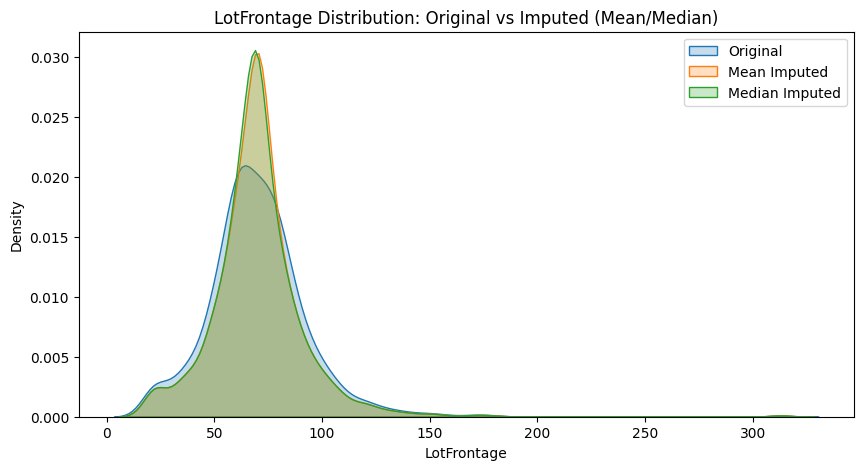

In [30]:

plt.figure(figsize=(10,5))
# kdeplot -> plot taht shows pdf
sns.kdeplot(df["LotFrontage"], label="Original", fill=True)
sns.kdeplot(df_mean["LotFrontage"], label="Mean Imputed", fill=True)
sns.kdeplot(df_median["LotFrontage"], label="Median Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean/Median)")
plt.show()

In [31]:
def compare_imputations(df_before, df_after, column_name):
    missing_indices = {column_name: df_before[df_before[column_name].isnull()].index.to_list() for column_name in df_before}

    if column_name not in missing_indices:
        print(f"No missing values were found in column '{column_name}'")
        return
    idx_list = missing_indices[column_name]

    comparison = pd.DataFrame({
        "Before": df_before.loc[idx_list, column_name],
        "After": df_after.loc[idx_list, column_name],
    })

    print(f"Changes in column: {column_name}")
    return comparison

## KNN Imputation (K-Nearest Neighbor)  -> ML Algorithm

In [32]:
from sklearn.impute import KNNImputer


In [33]:
knn_imputer = KNNImputer(n_neighbors=5)

In [34]:
df_knn = df_3.copy()

In [35]:
numerical_cols = df_knn.select_dtypes(include=[np.number]).columns
numerical_cols

Index(['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd',
       'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '2ndFlrSF',
       'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'Fireplaces', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', 'ScreenPorch', 'SalePrice'],
      dtype='str')

In [36]:
df_knn[numerical_cols] = knn_imputer.fit_transform(df_knn[numerical_cols])

In [37]:
compare_imputations(df_3, df_knn, 'LotFrontage')

Changes in column: LotFrontage


,Before,After
7,NaN,77.4
12,NaN,73.2
14,NaN,75.2
16,NaN,90.2
24,NaN,66.0
...,...,...
1429,NaN,82.2
1431,NaN,52.6
1441,NaN,34.2
1443,NaN,61.0


In [38]:
df_knn[numerical_cols].isnull().sum()

LotFrontage      0
LotArea          0
OverallQual      0
YearBuilt        0
YearRemodAdd     0
MasVnrArea       0
BsmtFinSF1       0
BsmtUnfSF        0
TotalBsmtSF      0
2ndFlrSF         0
GrLivArea        0
BsmtFullBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
Fireplaces       0
GarageCars       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
ScreenPorch      0
SalePrice        0
dtype: int64

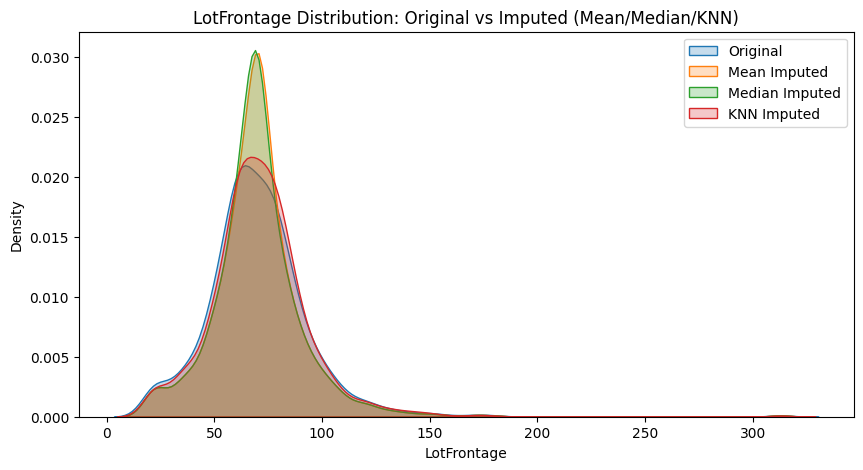

In [39]:
plt.figure(figsize=(10,5))
# kdeplot -> plot taht shows pdf
sns.kdeplot(df["LotFrontage"], label="Original", fill=True)
sns.kdeplot(df_mean["LotFrontage"], label="Mean Imputed", fill=True)
sns.kdeplot(df_median["LotFrontage"], label="Median Imputed", fill=True)
sns.kdeplot(df_knn["LotFrontage"], label="KNN Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean/Median/KNN)")
plt.show()

## Regression Imputation 

In [40]:
from sklearn.linear_model import LinearRegression

In [41]:
df_reg = df_3.copy()

In [42]:
train_data = df_reg.dropna(subset=["LotFrontage"])    # drop the rows where LotFrontage has null values
test_data = df_reg[df_reg["LotFrontage"].isnull()]

In [43]:
train_data.info()

<class 'pandas.DataFrame'>
Index: 1201 entries, 0 to 1459
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1201 non-null   str    
 1   LotFrontage    1201 non-null   float64
 2   LotArea        1201 non-null   int64  
 3   Street         1201 non-null   str    
 4   LotShape       1201 non-null   str    
 5   LandContour    1201 non-null   str    
 6   Utilities      1201 non-null   str    
 7   LotConfig      1201 non-null   str    
 8   LandSlope      1201 non-null   str    
 9   Neighborhood   1201 non-null   str    
 10  Condition1     1201 non-null   str    
 11  Condition2     1201 non-null   str    
 12  BldgType       1201 non-null   str    
 13  HouseStyle     1201 non-null   str    
 14  OverallQual    1201 non-null   int64  
 15  YearBuilt      1201 non-null   int64  
 16  YearRemodAdd   1201 non-null   int64  
 17  RoofStyle      1201 non-null   str    
 18  RoofMatl       1201 non-

In [44]:
target_corr_ml = df_reg.select_dtypes(include=[np.number]).corr()['LotFrontage'].abs()

In [45]:
target_corr_ml

LotFrontage      1.000000
LotArea          0.426095
OverallQual      0.251646
YearBuilt        0.123349
YearRemodAdd     0.088866
MasVnrArea       0.193458
BsmtFinSF1       0.233633
BsmtUnfSF        0.132644
TotalBsmtSF      0.392075
2ndFlrSF         0.080177
GrLivArea        0.402797
BsmtFullBath     0.100949
FullBath         0.198769
HalfBath         0.053532
BedroomAbvGr     0.263170
KitchenAbvGr     0.006069
Fireplaces       0.266639
GarageCars       0.285691
WoodDeckSF       0.088521
OpenPorchSF      0.151972
EnclosedPorch    0.010700
ScreenPorch      0.041383
SalePrice        0.351799
Name: LotFrontage, dtype: float64

In [46]:
X_train = train_data[["LotArea","OverallQual","TotalBsmtSF","GrLivArea"]]
Y_train = train_data["LotFrontage"]

In [47]:
reg = LinearRegression()

In [48]:
reg.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [49]:
reg.coef_

array([ 8.90135199e-04, -1.49550808e+00,  1.24430130e-02,  1.16904327e-02])

In [50]:
df_reg.loc[df_reg["LotFrontage"].isnull(), "LotFrontage"] = reg.predict(test_data[["LotArea","OverallQual","TotalBsmtSF","GrLivArea"]])

In [51]:
compare_imputations(df_3, df_reg, "LotFrontage",).head(10)

Changes in column: LotFrontage


,Before,After
7,NaN,76.480215
12,NaN,65.575403
14,NaN,70.486403
16,NaN,64.762909
24,NaN,64.943935
31,NaN,69.263614
42,NaN,60.980342
43,NaN,62.848844
50,NaN,69.936893
64,NaN,74.307034


## Filling missing values using Iterative Imputer (MICE)

In [52]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

In [53]:
cols_to_use = ["LotFrontage", "LotArea", "OverallQual", "GrLivArea"]

In [54]:
df_subset = df_3[cols_to_use].copy()

In [55]:
itr_imput = IterativeImputer(estimator=LinearRegression(), max_iter=10, random_state=10)

In [56]:
df_subset_imputed_values = itr_imput.fit_transform(df_subset)

In [57]:
df_subset[cols_to_use] = df_subset_imputed_values

In [58]:
df_subset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LotFrontage  1460 non-null   float64
 1   LotArea      1460 non-null   float64
 2   OverallQual  1460 non-null   float64
 3   GrLivArea    1460 non-null   float64
dtypes: float64(4)
memory usage: 45.8 KB


## Handling Outliers

In [59]:
df_3.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1460 non-null   str    
 1   LotFrontage    1201 non-null   float64
 2   LotArea        1460 non-null   int64  
 3   Street         1460 non-null   str    
 4   LotShape       1460 non-null   str    
 5   LandContour    1460 non-null   str    
 6   Utilities      1460 non-null   str    
 7   LotConfig      1460 non-null   str    
 8   LandSlope      1460 non-null   str    
 9   Neighborhood   1460 non-null   str    
 10  Condition1     1460 non-null   str    
 11  Condition2     1460 non-null   str    
 12  BldgType       1460 non-null   str    
 13  HouseStyle     1460 non-null   str    
 14  OverallQual    1460 non-null   int64  
 15  YearBuilt      1460 non-null   int64  
 16  YearRemodAdd   1460 non-null   int64  
 17  RoofStyle      1460 non-null   str    
 18  RoofMatl       1460

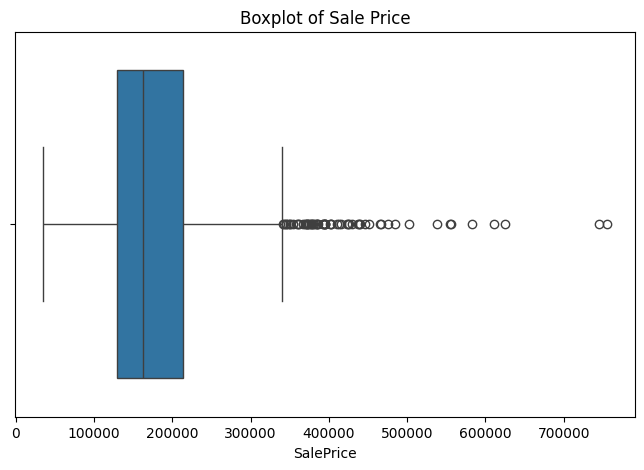

In [60]:
# Visualizing Outliers

plt.figure(figsize=(8,5))
sns.boxplot(x=df_3["SalePrice"])
plt.title("Boxplot of Sale Price")
plt.show()

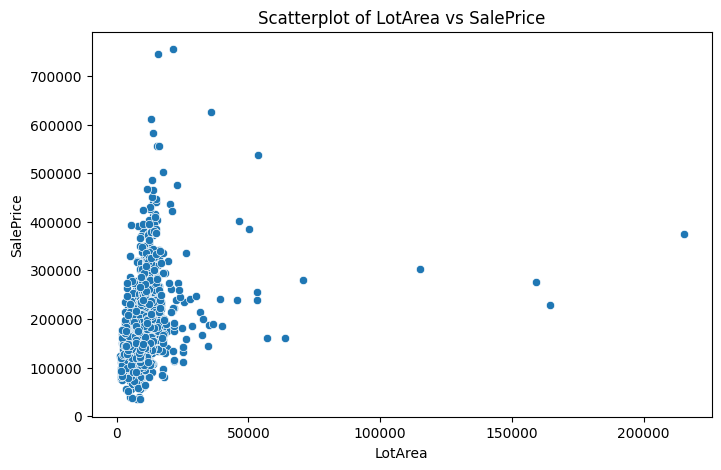

In [61]:
# Scatter plot LotArea vs SalePrice

plt.figure(figsize=(8,5))
sns.scatterplot(x=df_3["LotArea"], y=df_3["SalePrice"])
plt.title("Scatterplot of LotArea vs SalePrice")
plt.show()

In [62]:
# IQR Method

import numpy

In [63]:
def detect_outliers(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3-q1
    lower_fence = q1 - 1.5*iqr
    upper_fence = q3+1.5*iqr
    outliers = data[(data[col] < lower_fence) | (data[col] > upper_fence)]
    return outliers[col]

In [64]:
outlier_saleprice = detect_outliers(df_3, "SalePrice")

In [65]:
print(f"No of outliers in saleprice : {len(outlier_saleprice)}")

No of outliers in saleprice : 61


In [66]:
# How to check if data is normally distributed

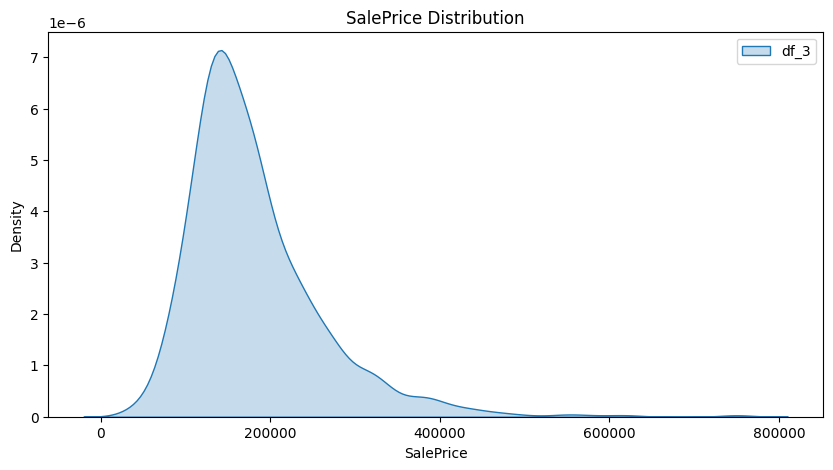

In [67]:
plt.figure(figsize=(10,5))
# kdeplot -> plot that shows pdf
sns.kdeplot(df_3["SalePrice"], label="df_3", fill=True)
plt.legend()
plt.title("SalePrice Distribution")
plt.show()

Text(0.5, 1.0, 'Histogram of Prices')

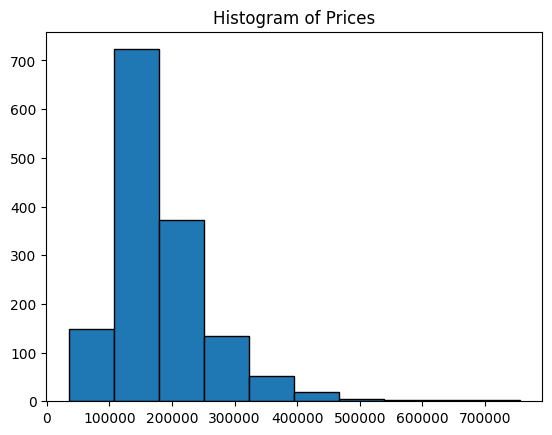

In [68]:
plt.hist(df_3["SalePrice"], bins=10, edgecolor="black")
plt.title("Histogram of Prices")

((array([-3.30513952, -3.04793228, -2.90489705, ...,  2.90489705,
          3.04793228,  3.30513952], shape=(1460,)),
  array([ 34900,  35311,  37900, ..., 625000, 745000, 755000], shape=(1460,))),
 (np.float64(74160.16474519417),
  np.float64(180921.19589041095),
  np.float64(0.9319665641512992)))

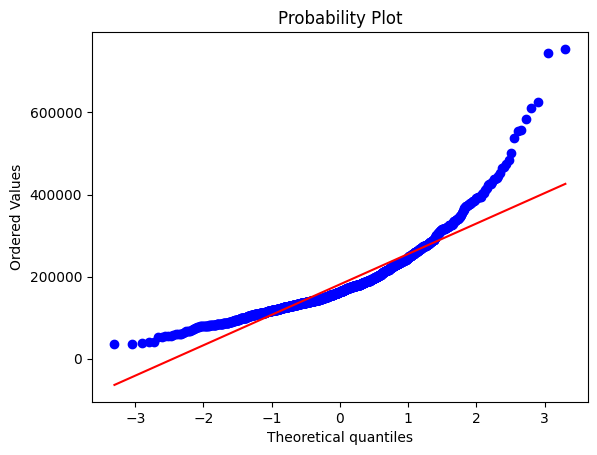

In [69]:
# Q-Q Plot

# If data follows a diagonal line, data is normal
import scipy.stats as stats
stats.probplot(df_3['SalePrice'], dist="norm", plot=plt)

In [70]:
# Shapiro-Wilk Test

alpha = 0.05 


# p = ?
""" value < p : data is normal
value > p : data is not normal """

stat, p = stats.shapiro(df["SalePrice"])
print("p-value",p)
if p > alpha:
    print("data looks normal")
else:
    print("data is not normal")

p-value 3.2061412312021656e-33
data is not normal


In [71]:
from scipy.stats import zscore

In [72]:
df["SalePrice_z"] = zscore(df["SalePrice"])
outliers_z = df[(df["SalePrice_z"].abs() > 3)]

In [73]:
print(f"Number of outliers in SalePrice (Z-Score): {len(outliers_z)}")
outliers_z[["SalePrice","SalePrice_z"]].head()

Number of outliers in SalePrice (Z-Score): 22


,SalePrice,SalePrice_z
58,438780,3.246967
178,501837,4.040982
185,475000,3.703050
349,437154,3.226492
389,426000,3.086040


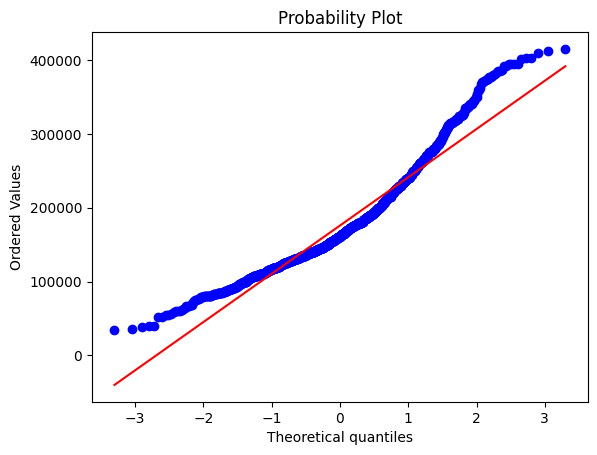

In [74]:
# Q-Q Plot without outliers in SalePrice

without_outliers_z = df[(df["SalePrice_z"].abs() <= 3)]
stats.probplot(without_outliers_z['SalePrice'], dist="norm", plot=plt)
plt.show()

In [75]:
# Modified Z-Score

from scipy.stats import  median_abs_deviation

In [76]:
median = df["SalePrice"].median()
mad = median_abs_deviation(df["SalePrice"])
cons_m_zscore = 0.6745

df["SalePrice_mod_z"] = cons_m_zscore * (df["SalePrice"] - median) / mad

outliers_mod_z = df[df["SalePrice_mod_z"].abs() > 3.5]

In [77]:
print(f"Number of outliers(Modified Z-Score) in SalePrice: {len(outliers_mod_z)}")
outliers_mod_z[["SalePrice","SalePrice_z", "SalePrice_mod_z"]].head()

Number of outliers(Modified Z-Score) in SalePrice: 51


,SalePrice,SalePrice_z,SalePrice_mod_z
53,385000,2.569767,3.940500
58,438780,3.246967,4.895095
112,383970,2.556797,3.922217
151,372402,2.411133,3.716886
161,412500,2.916048,4.428625


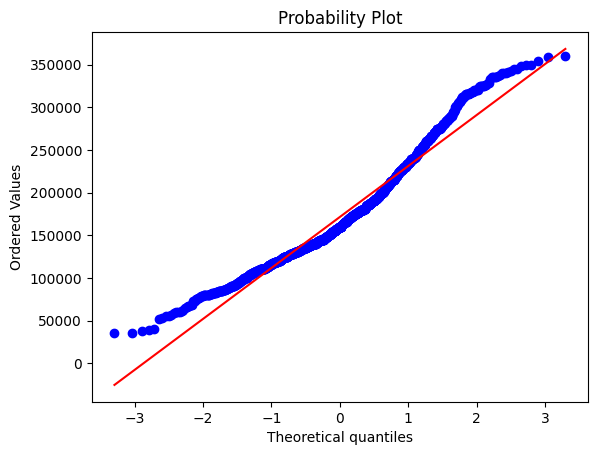

In [78]:
# Q-Q Plot without outliers in SalePrice (Z-Score modified)

without_outliers_z_mod = df[(df["SalePrice_mod_z"].abs() <= 3.5)]
stats.probplot(without_outliers_z_mod['SalePrice'], dist="norm", plot=plt)
plt.show()

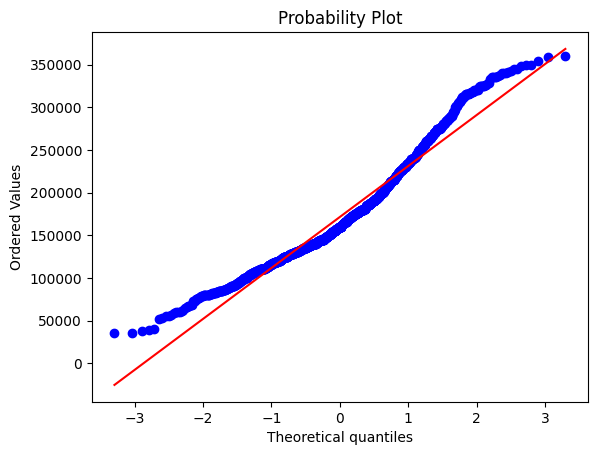

In [79]:
without_outliers_z_mod_v2 = df[(df["SalePrice_mod_z"] >= -3.5) & (df["SalePrice_mod_z"] <= 3.5)]
stats.probplot(without_outliers_z_mod_v2['SalePrice'], dist="norm", plot=plt)
plt.show()

In [80]:
# winsorization (Caping extreme values)
# Instead of deleting outliers, we cap them to a limit


In [81]:
from feature_engine.outliers import Winsorizer

In [82]:
winsor = Winsorizer(capping_method="quantiles", tail="both", fold=0.05, variables=["SalePrice"])
df_winsor = winsor.fit_transform(df)

In [83]:
# manual calculation
# calculate the 5th and 95th percentiles

percentile_5 = df["SalePrice"].quantile(0.05)
percentile_95 = df["SalePrice"].quantile(0.95)

print(f"5th percentile is {percentile_5}")
print(f"95th percentile is {percentile_95}")

5th percentile is 88000.0
95th percentile is 326099.9999999999


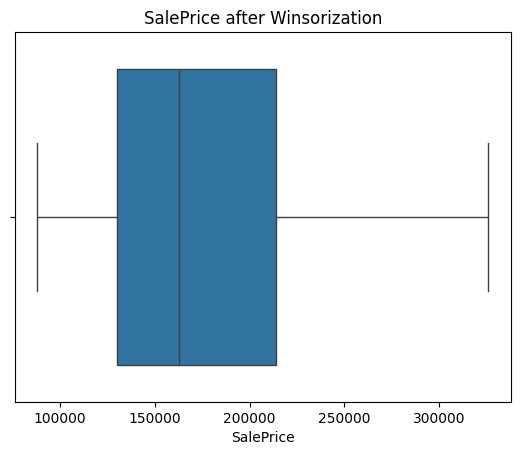

In [84]:
sns.boxplot(x=df_winsor["SalePrice"])
plt.title("SalePrice after Winsorization")
plt.show()

In [85]:
print(df.shape[0])
print(df_winsor.shape[0])

1460
1460


In [86]:
def compare_outliers(original_df, modified_df, column):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    sns.boxplot(x=original_df[column])
    plt.title(f"{column} - Before")

    plt.subplot(1,2,2)
    sns.boxplot(x=modified_df[column])
    plt.title(f"{column} - After")

    plt.show()


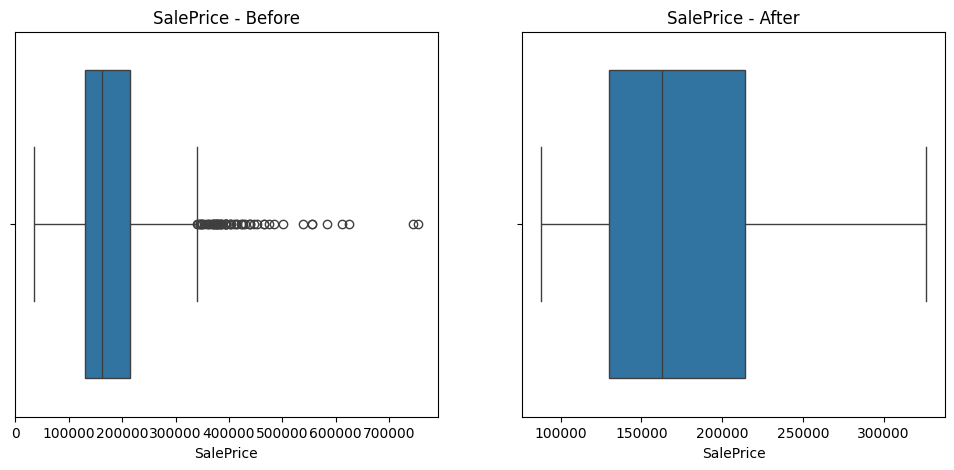

In [87]:
compare_outliers(df, df_winsor, "SalePrice")

## Feature Scaling 

- Many ML Algo (Linear, SVM, KNN, NN) are distance based or assume feature are on comparable scale.
- Eg. Age scale -> [0,100], Salary scale -> [0,100000]
- Scaling is a technique to make multiple features contribute equally.

In [88]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer

In [89]:
# utility
def summary_stats(series):
    return  {
        "mean": series.mean(),
        "std": series.std(),
        "skewness": series.skew(),
    }

In [90]:
def compare_distribution(original, transformed, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(original, bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f"{title} - Original")
    sns.histplot(transformed, bins=30, kde=True, ax=axes[1])
    axes[1].set_title(f"{title} - Transformed")
    plt.show()

Before:  {'mean': np.float64(70.04995836802665), 'std': np.float64(24.284751774483208), 'skewness': np.float64(2.1635691423248837)}
After:  {'mean': np.float64(-2.677107310003708e-16), 'std': np.float64(1.0004165798972613), 'skewness': np.float64(2.1635691423248846)}


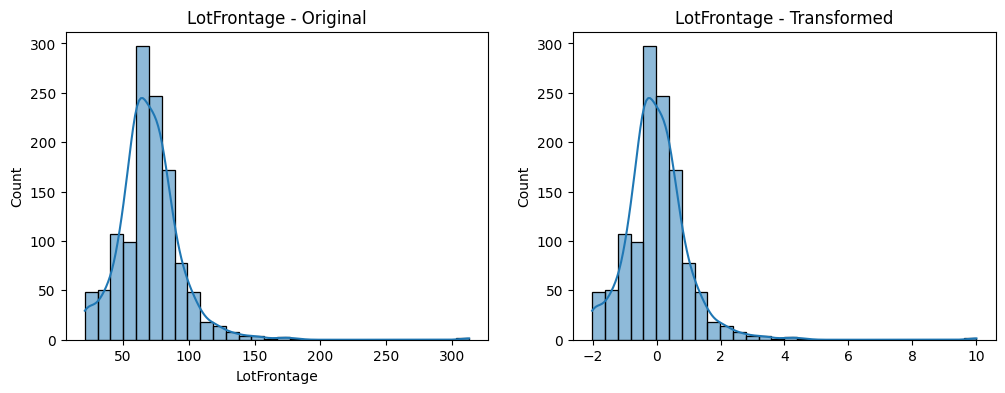

In [91]:
# Standard Scaling (Normal-Like data: LotFrontage)
# Formula: z = (x-mean)/std

col = "LotFrontage"
scaler = StandardScaler()
lot_scaled = scaler.fit_transform(df[[col]])
print("Before: ", summary_stats(df[col].dropna()))
print("After: ", summary_stats(pd.Series(lot_scaled.flatten())))
compare_distribution(df[col].dropna(), lot_scaled.flatten(), col)

Before:  {'mean': np.float64(70.04995836802665), 'std': np.float64(24.284751774483208), 'skewness': np.float64(2.1635691423248837)}
After:  {'mean': np.float64(0.1679793094795433), 'std': np.float64(0.0831669581317918), 'skewness': np.float64(2.1635691423248846)}


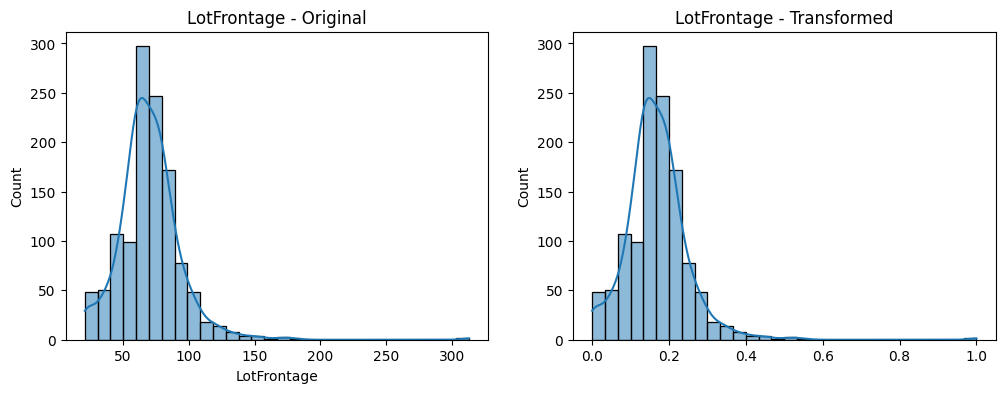

In [92]:
# Min Max Scaling (bounded features: OverallQual [1-10])
# Formula: x' = (x-min)/(max-min)

col = "LotFrontage"
scaler = MinMaxScaler()
lot_scaled = scaler.fit_transform(df[[col]])
print("Before: ", summary_stats(df[col].dropna()))
print("After: ", summary_stats(pd.Series(lot_scaled.flatten())))
compare_distribution(df[col].dropna(), lot_scaled.flatten(), col)

Before:  {'mean': np.float64(1515.463698630137), 'std': np.float64(525.4803834232025), 'skewness': np.float64(1.3665603560164552)}
After:  {'mean': np.float64(0.0795113149944179), 'std': np.float64(0.8118661775561259), 'skewness': np.float64(1.3665603560164554)}


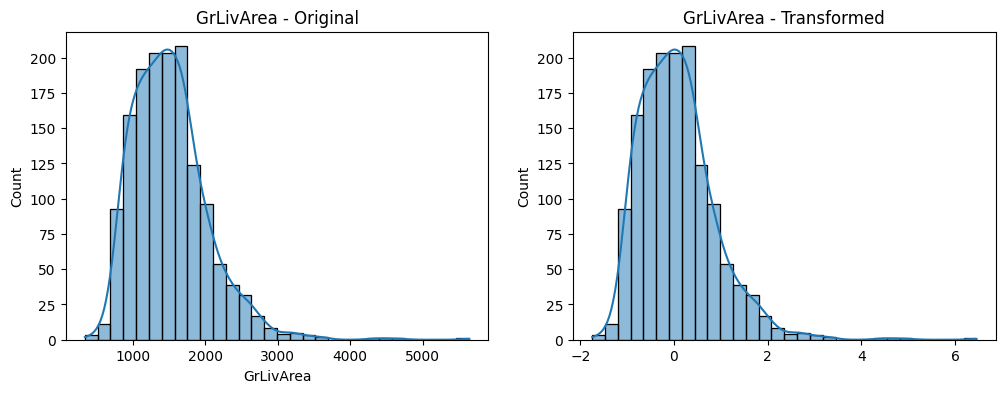

In [93]:
# Robust Scaling (outliers present: GrLivArea)
# Formula: x' = (x-median)/IQR

col = "GrLivArea"
scaler = RobustScaler()
lot_scaled = scaler.fit_transform(df[[col]])
print("Before: ", summary_stats(df[col].dropna()))
print("After: ", summary_stats(pd.Series(lot_scaled.flatten())))
compare_distribution(df[col].dropna(), lot_scaled.flatten(), col)

Before:  {'mean': np.float64(70.04995836802665), 'std': np.float64(24.284751774483208), 'skewness': np.float64(2.1635691423248837)}
After:  {'mean': np.float64(0.04999801752507831), 'std': np.float64(1.156416751165867), 'skewness': np.float64(2.163569142324884)}


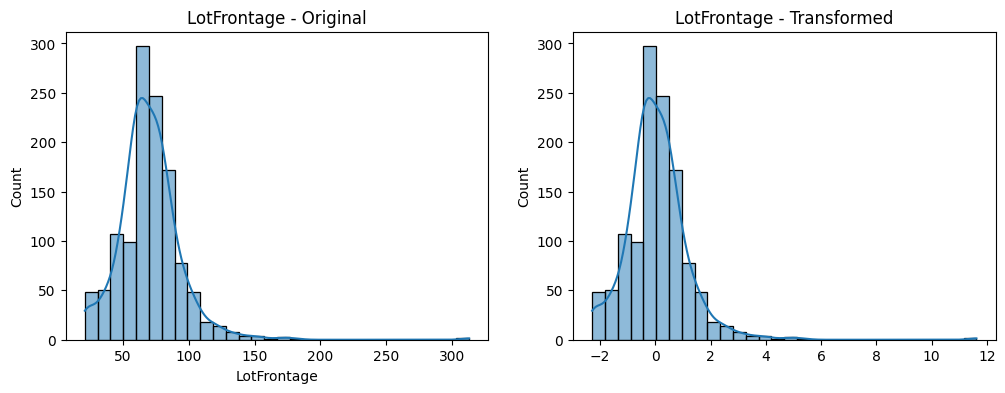

In [94]:
col = "LotFrontage"
scaler = RobustScaler()
lot_scaled = scaler.fit_transform(df[[col]])
print("Before: ", summary_stats(df[col].dropna()))
print("After: ", summary_stats(pd.Series(lot_scaled.flatten())))
compare_distribution(df[col].dropna(), lot_scaled.flatten(), col)

Before:  {'mean': np.float64(180921.19589041095), 'std': np.float64(79442.50288288662), 'skewness': np.float64(1.8828757597682129)}
After:  {'mean': np.float64(0.21328409271539375), 'std': np.float64(0.9454626942325095), 'skewness': np.float64(1.8828757597682129)}


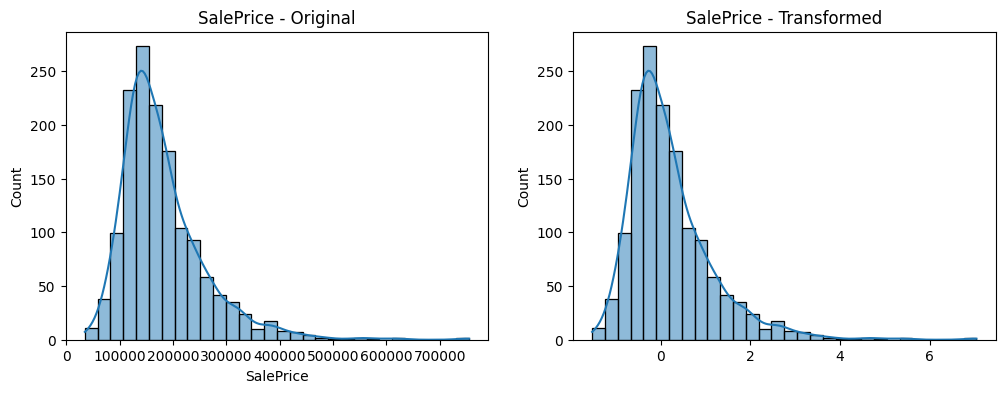

In [95]:
col = "SalePrice"
scaler = RobustScaler()
lot_scaled = scaler.fit_transform(df[[col]])
print("Before: ", summary_stats(df[col].dropna()))
print("After: ", summary_stats(pd.Series(lot_scaled.flatten())))
compare_distribution(df[col].dropna(), lot_scaled.flatten(), col)

Before:  {'mean': np.float64(180921.19589041095), 'std': np.float64(79442.50288288662), 'skewness': np.float64(1.8828757597682129)}
After:  {'mean': np.float64(12.024057394918406), 'std': np.float64(0.3994492733225068), 'skewness': np.float64(0.12134661989685333)}


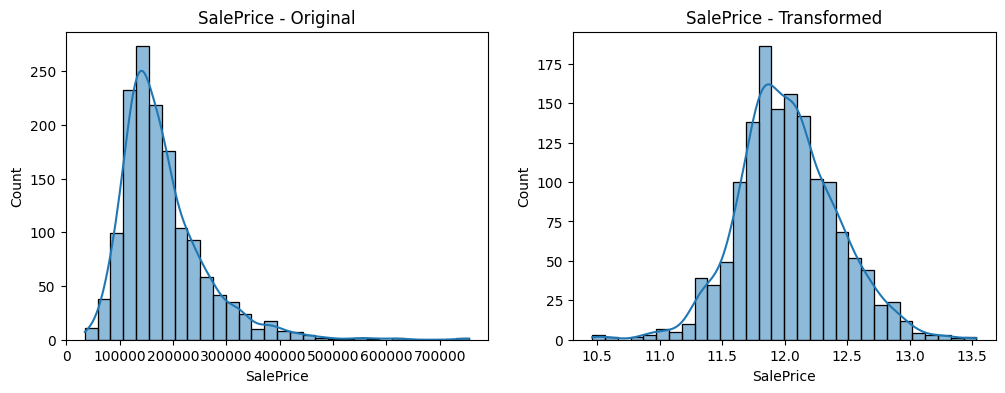

In [96]:
# Log Transformation (right-skewed data: SalePrice)
# Formula: x' = log(x+1)

col = "SalePrice"
log_transformed = np.log1p(df[col])
print("Before: ", summary_stats(df[col]))
print("After: ", summary_stats(log_transformed))
compare_distribution(df[col].dropna(), log_transformed, col)

Before:  {'mean': np.float64(10516.828082191782), 'std': np.float64(9981.26493237915), 'skewness': np.float64(12.207687851233496)}
After:  {'mean': np.float64(5.560240243876127e-16), 'std': np.float64(1.0003426417780867), 'skewness': np.float64(0.026687011208083273)}


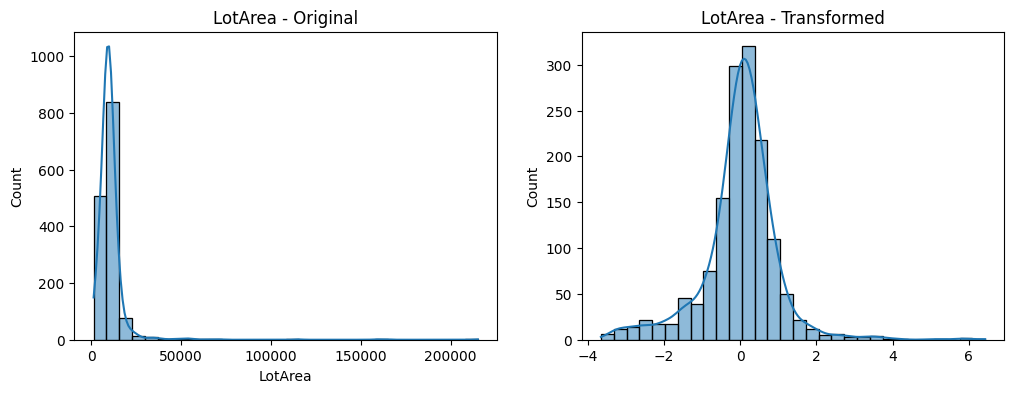

In [97]:
# Box-Cox/Yeo-Johnson (can handle left skewed data as well: LotArea)
# Yeo-Johnson formula adjusts depending on sign of x

col = "LotArea"
scaler = PowerTransformer(method="box-cox")
lot_scaled = scaler.fit_transform(df[[col]])
print("Before: ", summary_stats(df[col]))
print("After: ", summary_stats(pd.Series(lot_scaled.flatten())))
compare_distribution(df[col], lot_scaled.flatten(), col)

Before:  {'mean': np.float64(10516.828082191782), 'std': np.float64(9981.26493237915), 'skewness': np.float64(12.207687851233496)}
After:  {'mean': np.float64(9.490125580357503e-16), 'std': np.float64(1.0003426417780865), 'skewness': np.float64(0.026569113431683063)}


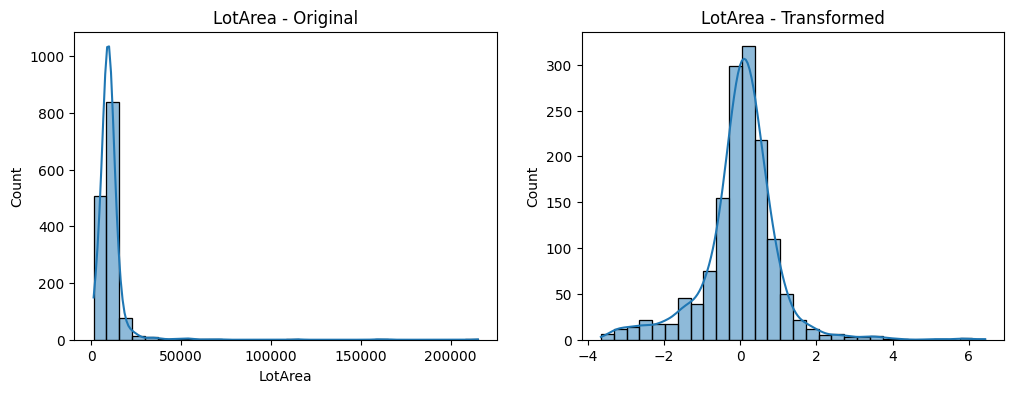

In [98]:
col = "LotArea"
scaler = PowerTransformer(method="yeo-johnson")
lot_scaled = scaler.fit_transform(df[[col]])
print("Before: ", summary_stats(df[col]))
print("After: ", summary_stats(pd.Series(lot_scaled.flatten())))
compare_distribution(df[col], lot_scaled.flatten(), col)

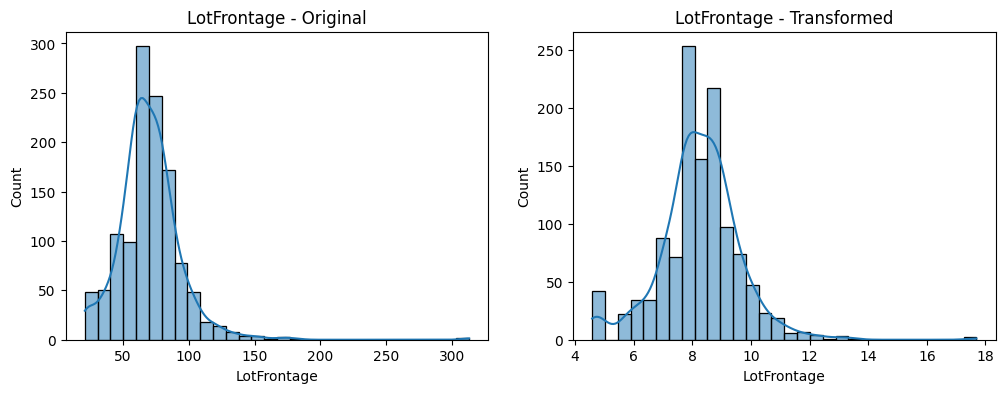

In [99]:
# square root transformation
# root of x

df_applied = df.copy()
col = "LotFrontage"
df_applied[col] = df_applied[col].apply(lambda x: np.sqrt(x))
compare_distribution(df[col], df_applied[col], col)

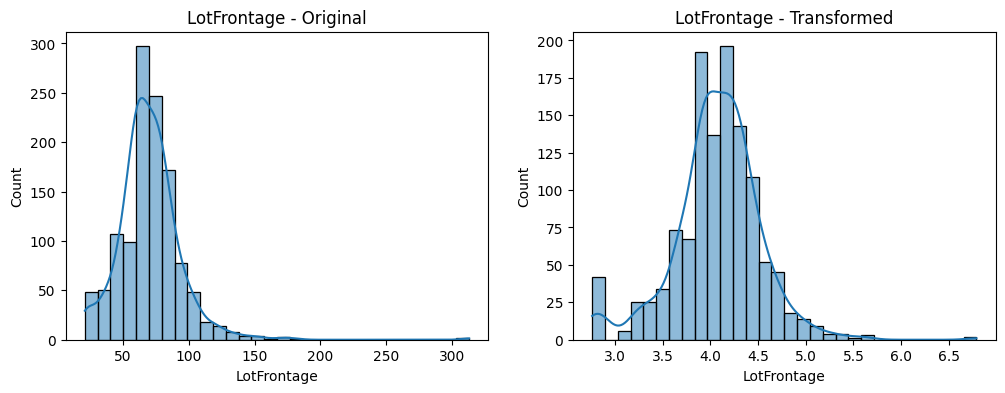

In [100]:
# cube root transformation
# root of x

df_applied = df.copy()
col = "LotFrontage"
df_applied[col] = df_applied[col].apply(lambda x: np.cbrt(x))
compare_distribution(df[col], df_applied[col], col)